In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
import io
import os
import sys
from PIL import Image
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from microfilm.microplot import microshow
from skimage.filters import gaussian, sobel
from skimage import measure, filters
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import label
from skimage.morphology import binary_opening
from skimage.segmentation import watershed

In [2]:
# with this peice of code, it will recognize the custom modules
project_root = "/Users/cgeyskens/Documents/code/phd/image-analysis/synapse-counting"
sys.path.append(project_root)

# custom modules
from synapse_counting import metadata, preprocessing, calc_synaptic_metrics

# input folder
input_folder = "/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_images"

# get a list of files in that input_folder
file_list = os.listdir(input_folder)
print(file_list)

['CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SO.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SR.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SL.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SO.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA3_SR.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_DG_Hilus.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_DG_ML.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_VCAM1-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi', 'CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_VCAM1-g

In [ ]:
file = "/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_images/CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_488-VGLUT1_647-PSD95_LacZ-gRNA_63X&3XzoomAiryscan_CA1_SLM.czi"
pixel_size_um, _ , image_size_um = metadata.extract_metadata(file)
pre, post = preprocessing.extract_and_split(file, presynapse_channel = 0, postsynapse_channel = 1)
p = preprocessing.ImagePreprocessing(
            include_rolling_ball = True, radius = 10, # rolling ball parameters
            include_clahe = True, clip_limit = 0.005, kernel_size = 150, nbins = 265, # CLAHE parameters
            include_tophat = True, element_size = 5, # tophat parameters
            include_blur = True, sigma = 1, preserve_range = True # gaussian blur filters
            )
pre_1, post_1 = p.preprocess(pre, post)
presynapse_threshold = filters.threshold_otsu(pre_1)
presynapse_thresholded = pre_1 > presynapse_threshold

In [ ]:
def custom_watershed(binarized_image, sigma=3):
    """
    Wrapper for watershed segmentation, copied from Robert Haase notebook:
    https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/20h_segmentation_post_processing/mimicking_imagej_watershed.html?highlight=watershed
    """
    distance = ndi.distance_transform_edt(binarized_image) # calculate distance image
    blurred_distance = gaussian(distance, sigma = sigma) # gaussian blur
    fp = np.ones((3,) * binarized_image.ndim) # neighbourhood size to find local maxima
    coords = peak_local_max(blurred_distance, footprint=fp, labels=binarized_image) # find local maxima
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers = label(mask)
    labels = watershed(-blurred_distance, markers, mask=binarized_image) # actual watershed
    edges_labels = sobel(labels)
    edges_binary = sobel(binarized_image)
    edges = np.logical_xor(edges_labels != 0, edges_binary != 0)
    almost = np.logical_not(edges) * binarized_image
    watershedded_image = binary_opening(almost)

    return watershedded_image

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(50,50))

for i, sigma in enumerate(np.arange(2, 6, 1)):
    result = preprocessing.custom_watershed(presynapse_thresholded, sigma=sigma)
    axs[0].imshow(presynapse_thresholded, cmap='gray')
    axs[1+i].imshow(result)
    axs[1+i].set_title("sigma="+str(sigma))

[[False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 ...
 [False False False ...  True False False]
 [False False False ...  True  True False]
 [False False False ...  True  True False]]


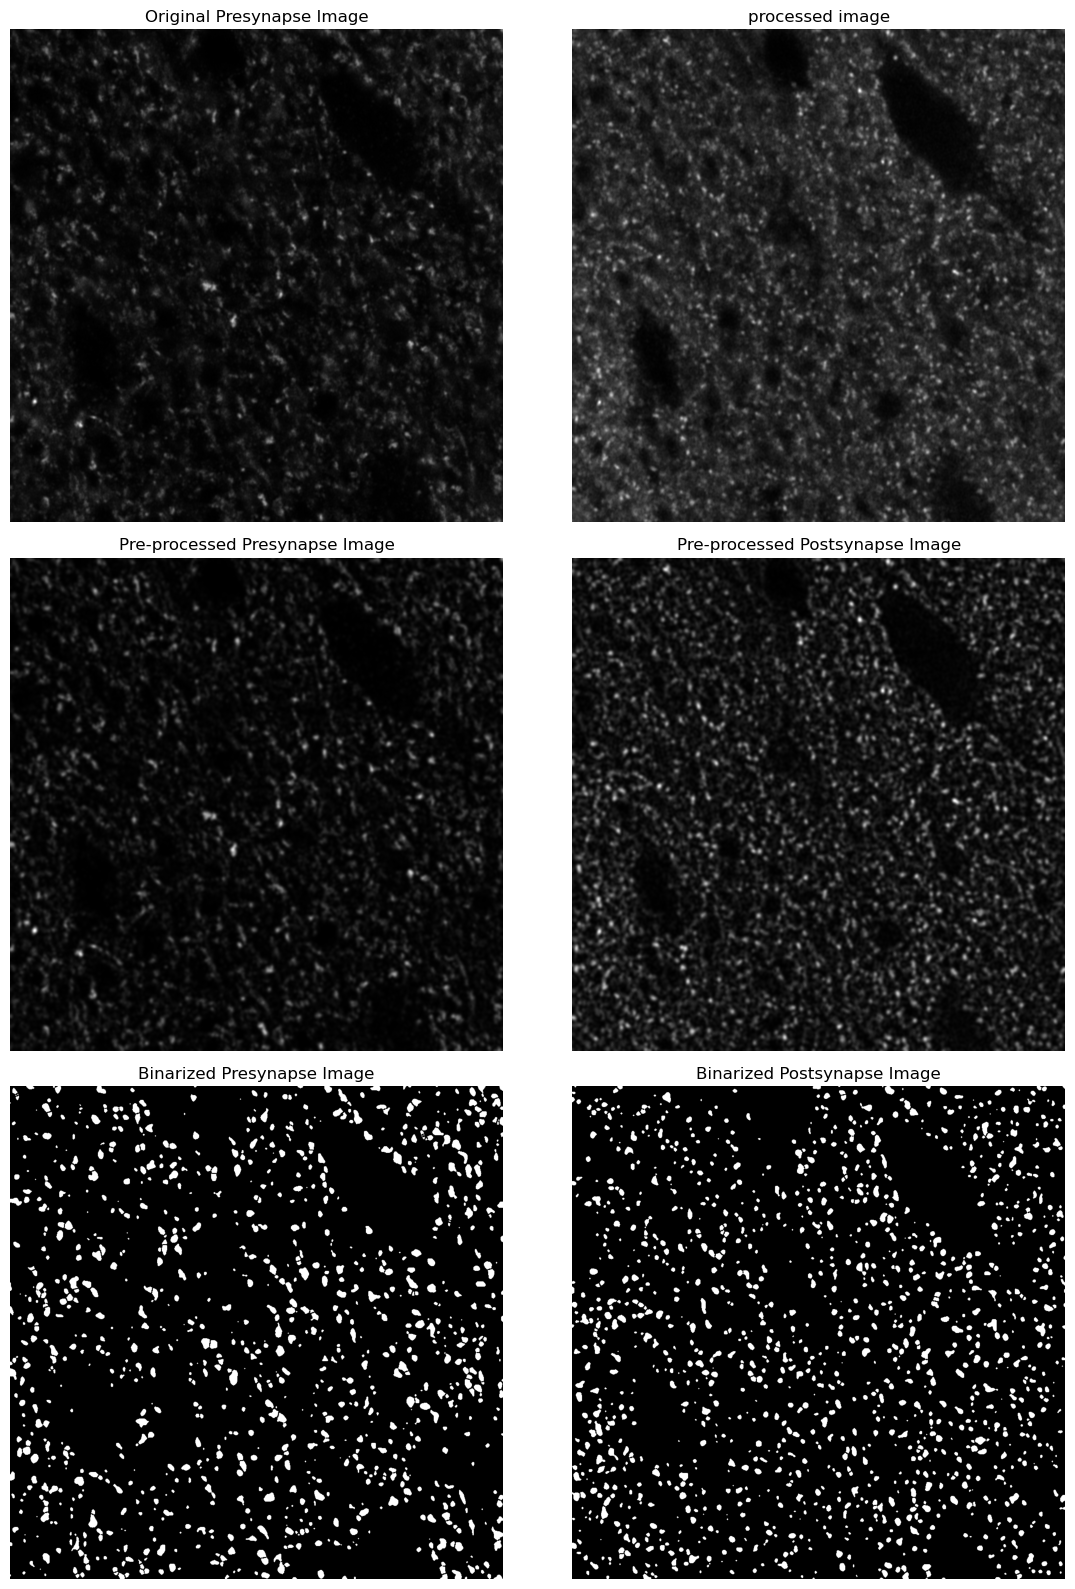

[[False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


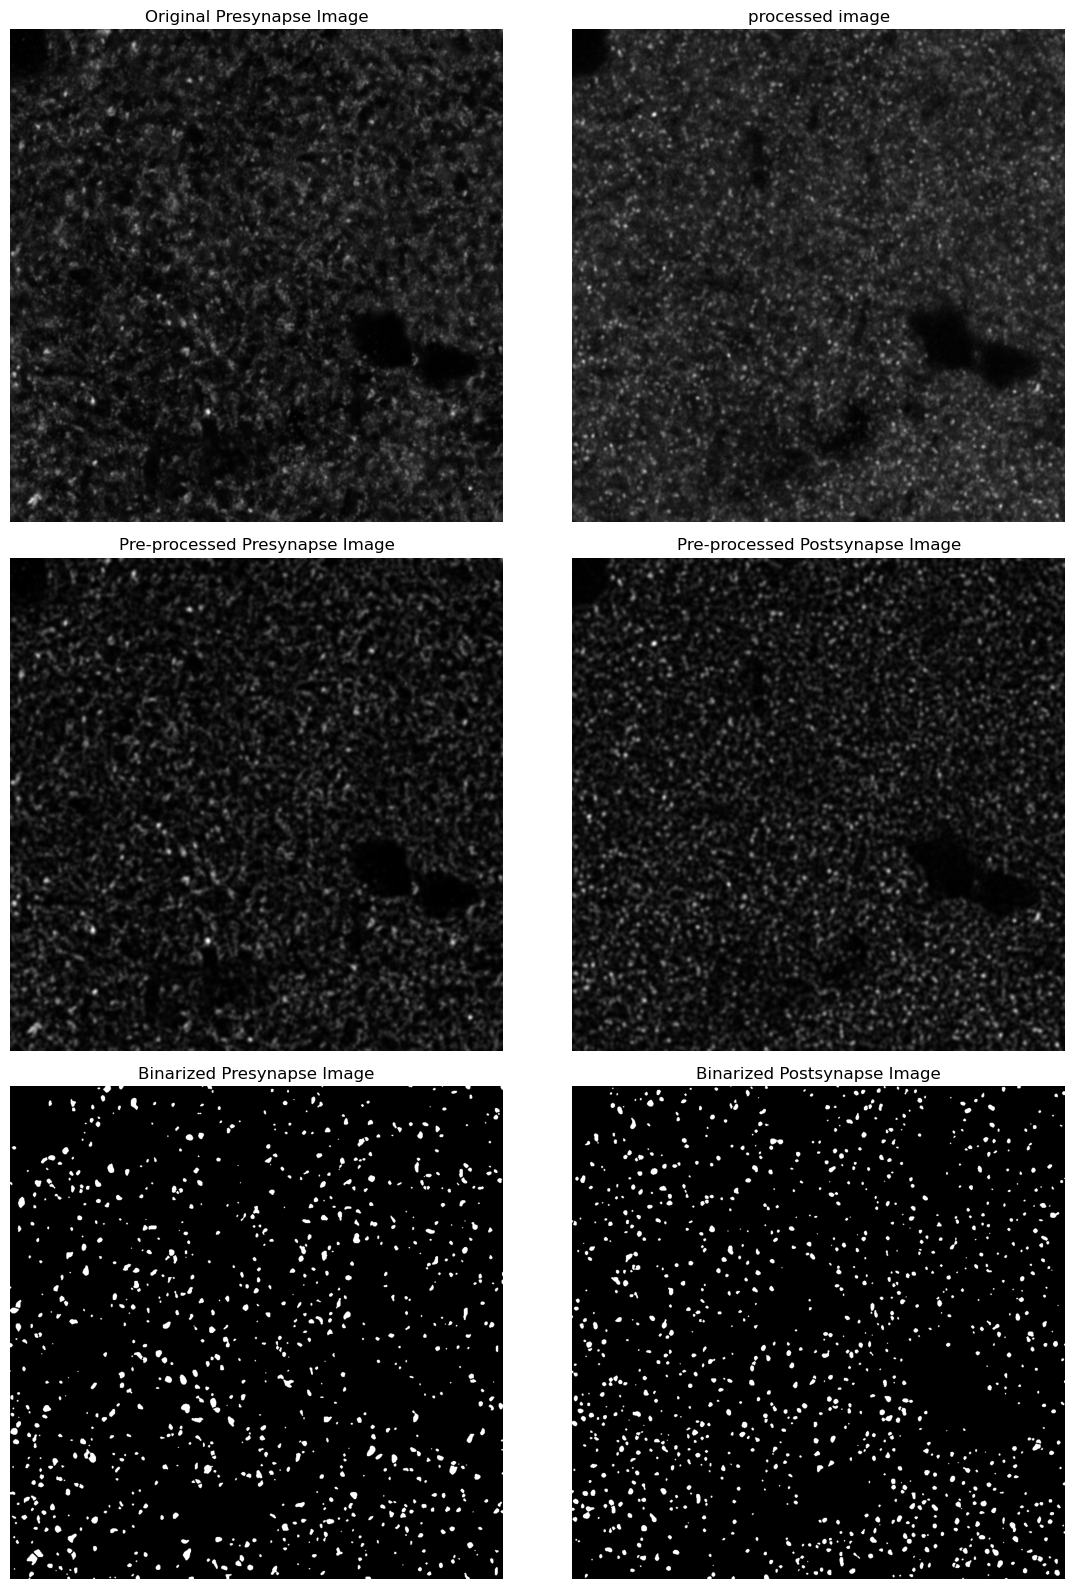

KeyboardInterrupt: 

In [3]:
big_synapses = {"CA3_SL.czi", "DG_Hilus.czi"}


for filename in file_list:
    file_path = os.path.join(input_folder, filename)
    parts = filename.split('_')[-2:]
    result = "_".join(parts)
    # extract metadata
    pixel_size_um, _ , image_size_um = metadata.extract_metadata(file_path)
    # splitting the channels
    pre, post = preprocessing.extract_and_split(file_path, presynapse_channel = 0, postsynapse_channel = 1)
    # parameters, based on big_synapse or not bi_synapse
    radius = 30 if result in big_synapses else 10
    element_size = 30 if result in big_synapses else 10
    watershed_sigma = 3 if result in big_synapses else 1.5
    # preprocessing
    p = preprocessing.ImagePreprocessing(
            include_rolling_ball=True, radius=radius,
            include_blur=True, sigma = 2, preserve_range = True,
            include_clahe=True,
            include_tophat=True, element_size = element_size
            )
    pre_1, post_1 = p.preprocess(pre, post)
    # thresholding and watershed segmentation
    presynapse_threshold, postsynapse_threshold = preprocessing.thresholding(pre_1, post_1, threshold_algorithm="triangle")
    print(presynapse_threshold)
    presynapse_watersheded = preprocessing.custom_watershed(presynapse_threshold, sigma = watershed_sigma)
    postsynapse_watersheded = preprocessing.custom_watershed(postsynapse_threshold, sigma = watershed_sigma)

    # Display the pre-processed and post-processed images
    fig, axes = plt.subplots(3, 2, figsize=(12, 16))

    axes[0, 0].imshow(pre, cmap='gray')
    axes[0, 0].set_title('Original Presynapse Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(post, cmap='gray')
    axes[0, 1].set_title('processed image')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(pre_1, cmap='gray')
    axes[1, 0].set_title('Pre-processed Presynapse Image')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(post_1, cmap='gray')
    axes[1, 1].set_title('Pre-processed Postsynapse Image')
    axes[1, 1].axis('off')

    axes[2, 0].imshow(presynapse_watersheded, cmap='gray')
    axes[2, 0].set_title('Binarized Presynapse Image')
    axes[2, 0].axis('off')

    axes[2, 1].imshow(postsynapse_watersheded, cmap='gray')
    axes[2, 1].set_title('Binarized Postsynapse Image')
    axes[2, 1].axis('off')

    plt.tight_layout()
    plt.show()
